In [31]:
import pandas as pd
df = pd.read_csv('titanic.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [32]:
df['Age'] = df['Age'].fillna(
    df.groupby('Sex')['Age'].transform(lambda x: round(x.mean()))
)

In [33]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,31.0,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [35]:
data = df.drop(['Pclass','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis = 1)

In [36]:
data

,PassengerId,Survived,Sex,Age,Fare
0,1,0,male,22.0,7.2500
1,2,1,female,38.0,71.2833
2,3,1,female,26.0,7.9250
3,4,1,female,35.0,53.1000
4,5,0,male,35.0,8.0500
...,...,...,...,...,...
886,887,0,male,27.0,13.0000
887,888,1,female,19.0,30.0000
888,889,0,female,28.0,23.4500
889,890,1,male,26.0,30.0000


In [37]:
dummies_sex = pd.get_dummies(data['Sex'],dtype=int)

In [38]:
merge = pd.concat([data,dummies_sex],axis=1)
merge

,PassengerId,Survived,Sex,Age,Fare,female,male
0,1,0,male,22.0,7.2500,0,1
1,2,1,female,38.0,71.2833,1,0
2,3,1,female,26.0,7.9250,1,0
3,4,1,female,35.0,53.1000,1,0
4,5,0,male,35.0,8.0500,0,1
...,...,...,...,...,...,...,...
886,887,0,male,27.0,13.0000,0,1
887,888,1,female,19.0,30.0000,1,0
888,889,0,female,28.0,23.4500,1,0
889,890,1,male,26.0,30.0000,0,1


In [ ]:
final = merge.drop(['Sex','female'],axis=1)

In [44]:
final.head(10)

,PassengerId,Survived,Age,Fare,male
0,1,0,22.0,7.2500,1
1,2,1,38.0,71.2833,0
2,3,1,26.0,7.9250,0
3,4,1,35.0,53.1000,0
4,5,0,35.0,8.0500,1
5,6,0,31.0,8.4583,1
6,7,0,54.0,51.8625,1
7,8,0,2.0,21.0750,1
8,9,1,27.0,11.1333,0
9,10,1,14.0,30.0708,0


<Axes: xlabel='Age'>

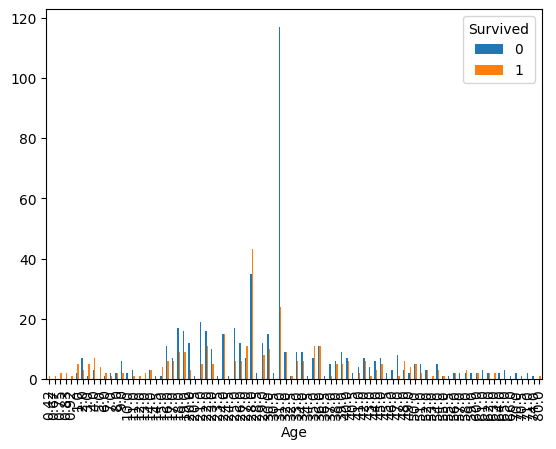

In [46]:
import matplotlib.pyplot as plt
pd.crosstab(data['Age'],data['Survived']).plot(kind='bar')

In [47]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [49]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test =train_test_split(final[['Age','Fare','male']],final['Survived'],test_size=0.2)

In [50]:
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
y_predict = model.predict(x_test)

In [51]:
model.score(x_test,y_test)

0.7486033519553073

In [54]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predict)

Text(95.72222222222221, 0.5, 'truth')

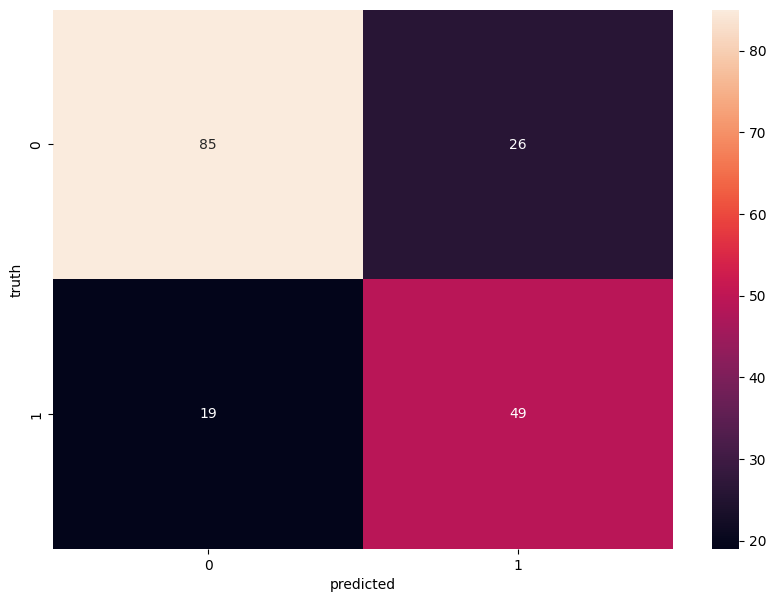

In [55]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('predicted')
plt.ylabel('truth')